In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [4]:
data = pd.read_csv("../data/processed_data.csv", index_col=0, parse_dates=True)
data.head()

,EEM,GLD,IWM,LQD,QQQ,SPY,TLT,VNQ,EEM_vol20,GLD_vol20,...,QQQ_mom50,SPY_mom50,TLT_mom50,VNQ_mom50,market_price,market_return,ma50,ma200,drawdown,regime
Date,,,,,,,,,,,,,,,,,,,,,
2005-10-17,0.010974,0.009781,0.001746,0.001391,0.003148,0.003701,-0.000223,0.005779,0.015855,0.008897,...,-0.032928,-0.026554,-0.008490,-0.033373,43.271372,0.003855,43.879468,42.513939,-0.029782,bull
2005-10-18,-0.025708,-0.005517,-0.013580,0.001296,-0.007097,-0.010889,0.001108,-0.009650,0.016647,0.009014,...,-0.032661,-0.035291,-0.005547,-0.006862,42.948885,-0.007481,43.869834,42.518100,-0.037040,sideways
2005-10-19,0.019343,-0.014142,0.021325,0.001017,0.019848,0.016498,0.000443,0.011220,0.017195,0.008672,...,-0.019772,-0.025125,-0.008790,-0.000328,43.326986,0.008765,43.863999,42.526939,-0.028600,bull
2005-10-20,-0.041061,-0.007799,-0.018754,-0.002499,-0.009353,-0.017772,0.002653,-0.015992,0.019142,0.008187,...,-0.020455,-0.041832,-0.005073,-0.025589,42.816533,-0.011851,43.847160,42.534736,-0.040112,sideways
2005-10-21,0.026265,0.011676,0.011009,0.005268,0.006245,0.003901,0.009230,0.009521,0.020349,0.008611,...,-0.022318,-0.041893,-0.002805,-0.029189,43.184587,0.008559,43.831306,42.544252,-0.031896,bull


In [5]:
#extract asset returns
returns = data[["SPY","QQQ","TLT","GLD","EEM","IWM","VNQ","LQD"]]
returns.head()

,SPY,QQQ,TLT,GLD,EEM,IWM,VNQ,LQD
Date,,,,,,,,
2005-10-17,0.003701,0.003148,-0.000223,0.009781,0.010974,0.001746,0.005779,0.001391
2005-10-18,-0.010889,-0.007097,0.001108,-0.005517,-0.025708,-0.013580,-0.009650,0.001296
2005-10-19,0.016498,0.019848,0.000443,-0.014142,0.019343,0.021325,0.011220,0.001017
2005-10-20,-0.017772,-0.009353,0.002653,-0.007799,-0.041061,-0.018754,-0.015992,-0.002499
2005-10-21,0.003901,0.006245,0.009230,0.011676,0.026265,0.011009,0.009521,0.005268


In [6]:
#equal weight returns
n_assets = returns.shape[1]
equal_weights = np.ones(n_assets) / n_assets
equal_weights

array([0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125, 0.125])

In [7]:
#equal weight returns
ew_returns = returns.dot(equal_weights)
ew_returns.head()

Date
2005-10-17    0.004537
2005-10-18   -0.008755
2005-10-19    0.009444
2005-10-20   -0.013822
2005-10-21    0.010389
dtype: float64

In [8]:
#mean variance opti
def min_variance_weights(cov_matrix):
    n = cov_matrix.shape[0]
    init_weights = np.ones(n) / n
    
    def portfolio_variance(weights):
        return weights.T @ cov_matrix @ weights
    
    constraints = ({
        "type":"eq",
        "fun": lambda w: np.sum(w) - 1
    })
    bounds = tuple((0,1) for _ in range(n))
    result = minimize(
        portfolio_variance,
        init_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints
    )
    
    if result.success:
        return result.x
    else:
        return init_weights

In [9]:
#rolling portfolio optimization
#rebalce every 21 days 
rebalance_period = 21
lookback = 252

mv_returns = []
mv_dates = []
mv_weights_history = []

In [10]:
for i in range(lookback, len(returns), rebalance_period):
    train = returns.iloc[i-lookback:i]
    cov = train.cov().values
    weights = min_variance_weights(cov)
    test_period = returns.iloc[i:i+rebalance_period]
    for date, row in test_period.iterrows():
        port_ret = row.values @ weights
        mv_returns.append(port_ret)
        mv_dates.append(date)
        mv_weights_history.append(weights)

In [11]:
mv_results = pd.DataFrame({
    "portfolio_return": mv_returns
}, index=mv_dates)
mv_results.head()

,portfolio_return
2006-10-17,-0.005241
2006-10-18,0.001826
2006-10-19,0.002467
2006-10-20,-0.003077
2006-10-23,-0.000241


In [12]:
#trans cost 
transaction_cost = 0.001
#turnover calc
turnovers = [0]
for i in range(1,len(mv_weights_history)):
    
    turnover = np.sum(
        np.abs(
            mv_weights_history[i] - mv_weights_history[i-1]
        )
    )
    turnovers.append(turnover)

In [13]:
#cost apply 
mv_results = mv_results.iloc[:len(turnovers)].copy()
mv_results["turnover"] = turnovers
mv_results["transaction_cost"] = mv_results["turnover"] * transaction_cost
mv_results["net_return"] = (
    mv_results["portfolio_return"] - mv_results["transaction_cost"]
)
mv_results.head()

,portfolio_return,turnover,transaction_cost,net_return
2006-10-17,-0.005241,0.0,0.0,-0.005241
2006-10-18,0.001826,0.0,0.0,0.001826
2006-10-19,0.002467,0.0,0.0,0.002467
2006-10-20,-0.003077,0.0,0.0,-0.003077
2006-10-23,-0.000241,0.0,0.0,-0.000241


In [14]:
#equal weight result 
ew_results = pd.DataFrame({
    "net_return": ew_returns
})

ew_results = ew_results.loc[mv_results.index]

In [15]:
#performance matrics 
def sharpe_ratio(r):
    return np.sqrt(252) * r.mean() / r.std()

def max_drawdown(r):
    cumulative = (1+r).cumprod()
    peak = cumulative.cummax()
    drawdown = cumulative / peak - 1
    return drawdown.min()

def annual_volatility(r):
    return r.std() * np.sqrt(252)

def cumulative_return(r):
    return (1+r).cumprod().iloc[-1] - 1

In [16]:
#strategy comparison
metrics = pd.DataFrame({

"Equal Weight":{     "Sharpe": sharpe_ratio(ew_results["net_return"]), 
                    "MaxDrawdown": max_drawdown(ew_results["net_return"]),
                    "Volatility": annual_volatility(ew_results["net_return"]),
                    "CumulativeReturn": cumulative_return(ew_results["net_return"])
},

"MeanVariance":{
                    "Sharpe": sharpe_ratio(mv_results["net_return"]),
                    "MaxDrawdown": max_drawdown(mv_results["net_return"]),
                    "Volatility": annual_volatility(mv_results["net_return"]),
                    "CumulativeReturn": cumulative_return(mv_results["net_return"])
}}).T
metrics

,Sharpe,MaxDrawdown,Volatility,CumulativeReturn
Equal Weight,0.473112,-0.444806,0.144973,1.872438
MeanVariance,0.472973,-0.399774,0.133298,1.675118


In [17]:
#total returns 
ew_total = (1 + ew_results["net_return"]).cumprod()
mv_total = (1 + mv_results["net_return"]).cumprod()

In [18]:
ew_results.to_csv("../results/ew_returns.csv")
mv_results.to_csv("../results/mv_returns.csv")
print("saved both ew and mv returns.csv")

saved both ew and mv returns.csv


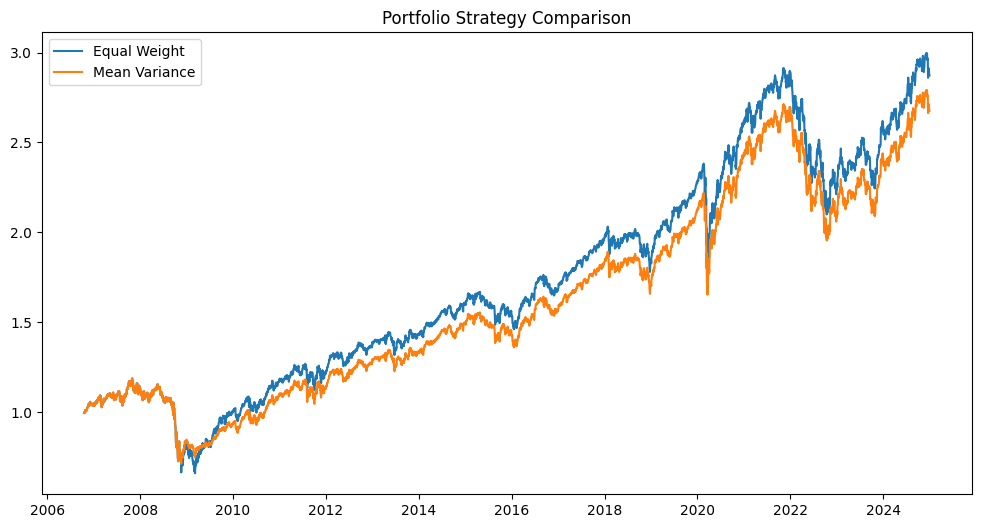

In [19]:
#comparison
plt.figure(figsize=(12,6))
plt.plot(ew_total, label="Equal Weight")
plt.plot(mv_total, label="Mean Variance")
plt.legend()
plt.title("Portfolio Strategy Comparison")
plt.show()

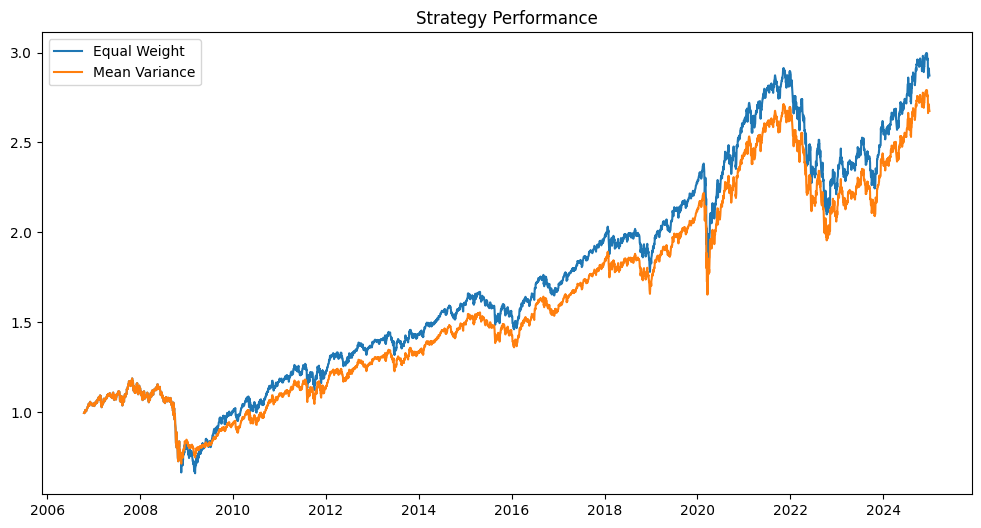

In [20]:
metrics.to_csv("../results/metrics.csv")
plt.figure(figsize=(12,6))
plt.plot(ew_total,label="Equal Weight")
plt.plot(mv_total,label="Mean Variance")
plt.legend()
plt.title("Strategy Performance")
plt.savefig("../results/nav_comparison.png")